# Regresi Prediksi Maintenance Motor
Notebook ini memuat EDA dan training model Regresi untuk memprediksi sisa hari sebelum maintenance (R2 Score > 0.85).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Load Data
df = pd.read_csv("motor_dataset.csv")

## Exploratory Data Analysis (EDA)

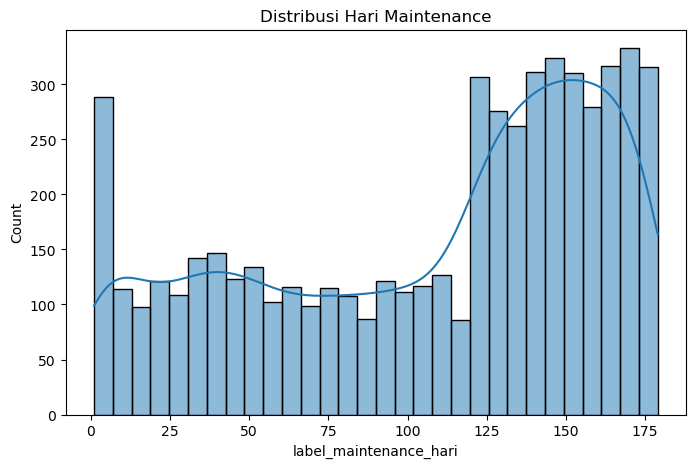

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(df["label_maintenance_hari"], bins=30, kde=True)
plt.title("Distribusi Hari Maintenance")
plt.show()

## Preprocessing & Training

In [3]:
X = df.drop(["label_kondisi", "label_maintenance_hari"], axis=1)
y = df["label_maintenance_hari"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9195149157964222
Mean Absolute Error (MAE): 12.788763636363635


In [4]:
# Simpan Model
joblib.dump(model, "best_reg_model.pkl")
print("Model Regresi berhasil disimpan!")

Model Regresi berhasil disimpan!
